<a href="https://colab.research.google.com/github/knc6/jarvis-tools-notebooks/blob/master/jarvis-tools-notebooks/scaling_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install alignn slakonet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.4/170.4 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.9/145.9 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 127.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 120.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 7.1 MB/s eta 0:00:00


In [2]:
%matplotlib inline
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from jarvis.db.figshare import get_jid_data
from jarvis.core.atoms import Atoms

# ALIGNN-FF (non-DGL default model via calculator)
from alignn.ff.ff import AlignnAtomwiseCalculator, default_path

# SlakoNet
from slakonet.atoms import Geometry
from slakonet.optim import get_atoms, default_model
from slakonet.main import generate_shell_dict_upto_Z65

# ── 1. Setup (GPU only) ───────────────────────────────────────────────────────
assert torch.cuda.is_available(), "No CUDA device found — this benchmark is GPU-only."
device = "cuda"

# shared base structure: Si (JVASP-1002)
dat   = get_jid_data(jid="JVASP-1002", dataset="dft_3d")
atoms = Atoms.from_dict(dat["atoms"])
print("base cell:", atoms.composition.reduced_formula, "| atoms:", atoms.num_atoms)

MAX_ATOMS = 1100
N_REPEATS = 3

# ALIGNN model
alignn_calc = AlignnAtomwiseCalculator(path=default_path(), device=device)

# SlakoNet model
sk_model    = default_model()
shell_dict  = generate_shell_dict_upto_Z65()
kpoints     = torch.tensor([1, 1, 1])

# ── 2. Warmup ─────────────────────────────────────────────────────────────────
warm = atoms.make_supercell_matrix([2, 2, 2]).ase_converter()
warm.calc = alignn_calc
_ = warm.get_potential_energy()
torch.cuda.synchronize()

# ── 3. Scaling benchmark ──────────────────────────────────────────────────────
num_atoms, t_alignn, t_slako = [], [], []

for i in tqdm(range(1, 12), desc="Scaling (GPU)"):
    sc = atoms.make_supercell_matrix([i, i, i])
    n  = sc.num_atoms
    if n > MAX_ATOMS:
        break
    num_atoms.append(n)

    # --- ALIGNN-FF ---
    ase_sc = sc.ase_converter()
    ase_sc.calc = alignn_calc
    try:
        ts = []
        for _ in range(N_REPEATS):
            torch.cuda.synchronize(); t0 = time.perf_counter()
            e = ase_sc.get_potential_energy()
            torch.cuda.synchronize(); ts.append(time.perf_counter() - t0)
        t_alignn.append(np.median(ts))
    except torch.cuda.OutOfMemoryError:
        print(f"  [ALIGNN OOM] N={n}"); t_alignn.append(float("nan")); torch.cuda.empty_cache()

    # --- SlakoNet ---
    geometry = Geometry.from_ase_atoms([sc.ase_converter()])
    try:
        ts = []
        for _ in range(N_REPEATS):
            with torch.no_grad():
                torch.cuda.synchronize(); t0 = time.perf_counter()
                props, success = sk_model.compute_multi_element_properties(
                    geometry=geometry, shell_dict=shell_dict,
                    kpoints=kpoints, get_energy=True, device="cuda",
                )
                torch.cuda.synchronize(); ts.append(time.perf_counter() - t0)
        t_slako.append(np.median(ts))
    except torch.cuda.OutOfMemoryError:
        print(f"  [SlakoNet OOM] N={n}"); t_slako.append(float("nan")); torch.cuda.empty_cache()

    print(f"  sc={i:2d}  N={n:5d}  ALIGNN={t_alignn[-1]:.3f}s  SlakoNet={t_slako[-1]:.3f}s")

num_atoms = np.array(num_atoms)
t_alignn  = np.array(t_alignn)
t_slako   = np.array(t_slako)

# ── 4. Summary + power-law fits ───────────────────────────────────────────────
def fit(N, t):
    m = np.isfinite(t)
    if m.sum() < 3: return None
    a, c = np.polyfit(np.log(N[m]), np.log(t[m]), 1)
    return a, np.exp(c)

print("\nnum_atoms :", num_atoms.tolist())
print("ALIGNN    :", [f"{t:.3f}" for t in t_alignn])
print("SlakoNet  :", [f"{t:.3f}" for t in t_slako])

fa = fit(num_atoms, t_alignn)
fs = fit(num_atoms, t_slako)
if fa: print(f"\nALIGNN-FF:  t ~ {fa[1]:.2e} * N^{fa[0]:.2f}")
if fs: print(f"SlakoNet:   t ~ {fs[1]:.2e} * N^{fs[0]:.2f}")

# ── 5. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(num_atoms, t_alignn, "s--", color="tomato",   lw=2, ms=6, label="ALIGNN-FF")
ax.plot(num_atoms, t_slako,  "o-",  color="steelblue", lw=2, ms=6, label="SlakoNet")

nf = np.linspace(num_atoms.min(), num_atoms.max(), 100)
if fa: ax.plot(nf, fa[1]*nf**fa[0], ":", color="darkred",  alpha=0.6, label=f"ALIGNN $N^{{{fa[0]:.2f}}}$")
if fs: ax.plot(nf, fs[1]*nf**fs[0], ":", color="navy",     alpha=0.6, label=f"SlakoNet $N^{{{fs[0]:.2f}}}$")

ax.set_xlabel("Number of atoms")
ax.set_ylabel("Inference time (s)")
ax.set_title(f"GPU scaling: ALIGNN-FF vs SlakoNet — {atoms.composition.reduced_formula} supercells")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("alignn_vs_slakonet_scaling.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → alignn_vs_slakonet_scaling.png")

Obtaining 3D dataset 94k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699


100%|██████████| 48.4M/48.4M [00:04<00:00, 10.4MiB/s]


Loading the zipfile...
Loading completed.
base cell: Si | atoms: 2
dir_path /root/.cache/atomgptlab/alignn_ff/mps


100%|██████████| 563k/563k [00:00<00:00, 720kiB/s]


100%|██████████| 183M/183M [00:14<00:00, 12.6MiB/s]


...

Scaling (GPU):  64%|██████▎   | 7/11 [07:46<05:19, 79.88s/it]

  sc= 7  N=  686  ALIGNN=0.531s  SlakoNet=37.385s
potential_energy 0
electronic_energy tensor(-36740.0625, device='cuda:0')
potential_energy 0
electronic_energy tensor(-36740.0625, device='cuda:0')
potential_energy 0
electronic_energy tensor(-36740.0625, device='cuda:0')


Scaling (GPU):  73%|███████▎  | 8/11 [11:00<04:07, 82.54s/it] 

  sc= 8  N= 1024  ALIGNN=1.007s  SlakoNet=63.752s

num_atoms : [2, 16, 54, 128, 250, 432, 686, 1024]
ALIGNN    : ['0.148', '0.149', '0.265', '0.168', '0.226', '0.271', '0.531', '1.007']
SlakoNet  : ['17.218', '17.216', '17.924', '17.831', '20.259', '25.390', '37.385', '63.752']

ALIGNN-FF:  t ~ 8.87e-02 * N^0.24
SlakoNet:   t ~ 1.13e+01 * N^0.16


Saved → alignn_vs_slakonet_scaling.png


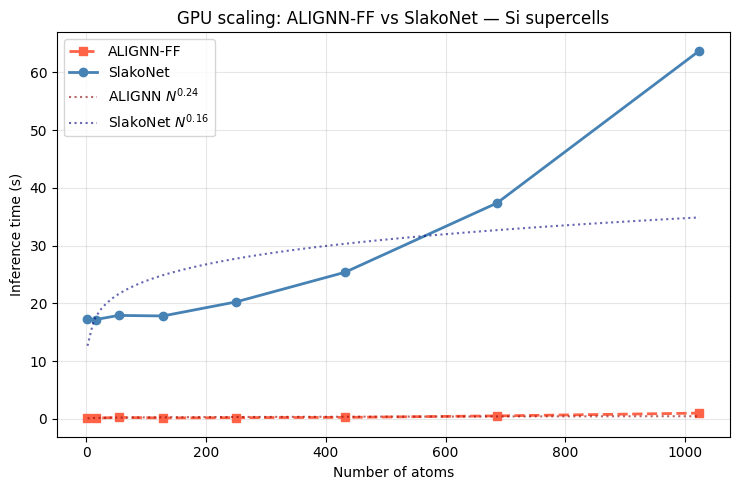

In [3]:
%matplotlib inline
ax.set_xlabel("Number of atoms")
ax.set_ylabel("Inference time (s)")
ax.set_title(f"GPU scaling: ALIGNN-FF vs SlakoNet — {atoms.composition.reduced_formula} supercells")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()